# Анализ банков в период 2024–2026 гг.
## Влияние макроэкономических факторов на прибыль банков

**Автор:** Метриков Владислав Александрович  
**Дата:** май 2026 г.

---

### Цель исследования
Факторный анализ влияния ключевой ставки ЦБ РФ и денежной массы M2 на операционную эффективность трёх системообразующих банков РФ:
- **Т-Технологии** (финтех-модель)
- **Сбербанк** (классический универсальный банк)
- **ВТБ** (корпоративный банк)

### Анализируемые метрики
- **NIM** — чистая процентная маржа
- **ROE** — рентабельность капитала
- **CoR** — стоимость риска
- **Net Profit** — чистая прибыль

### Структура ноутбука
1. Загрузка и подготовка данных
2. Влияние ключевой ставки на чистую прибыль банков
3. Регрессионный анализ ROE vs ключевая ставка (Т-Технологии, Сбер, ВТБ)
4. Динамика кредитных портфелей vs M2
5. Сравнение ROE банков
6. Сравнение комиссионных доходов
7. Динамика роста комиссионных доходов
8. Прогноз ROE на остаток 2026 года

### Данные
Файл `t_blank.xlsx` — ежеквартальная консолидированная отчётность МСФО за 2024–2026 гг.

---
> **Для запуска:** положите файл `t_blank.xlsx` в ту же папку что и этот ноутбук.

## 1. Загрузка данных и визуализация: Влияние ключевой ставки на чистую прибыль

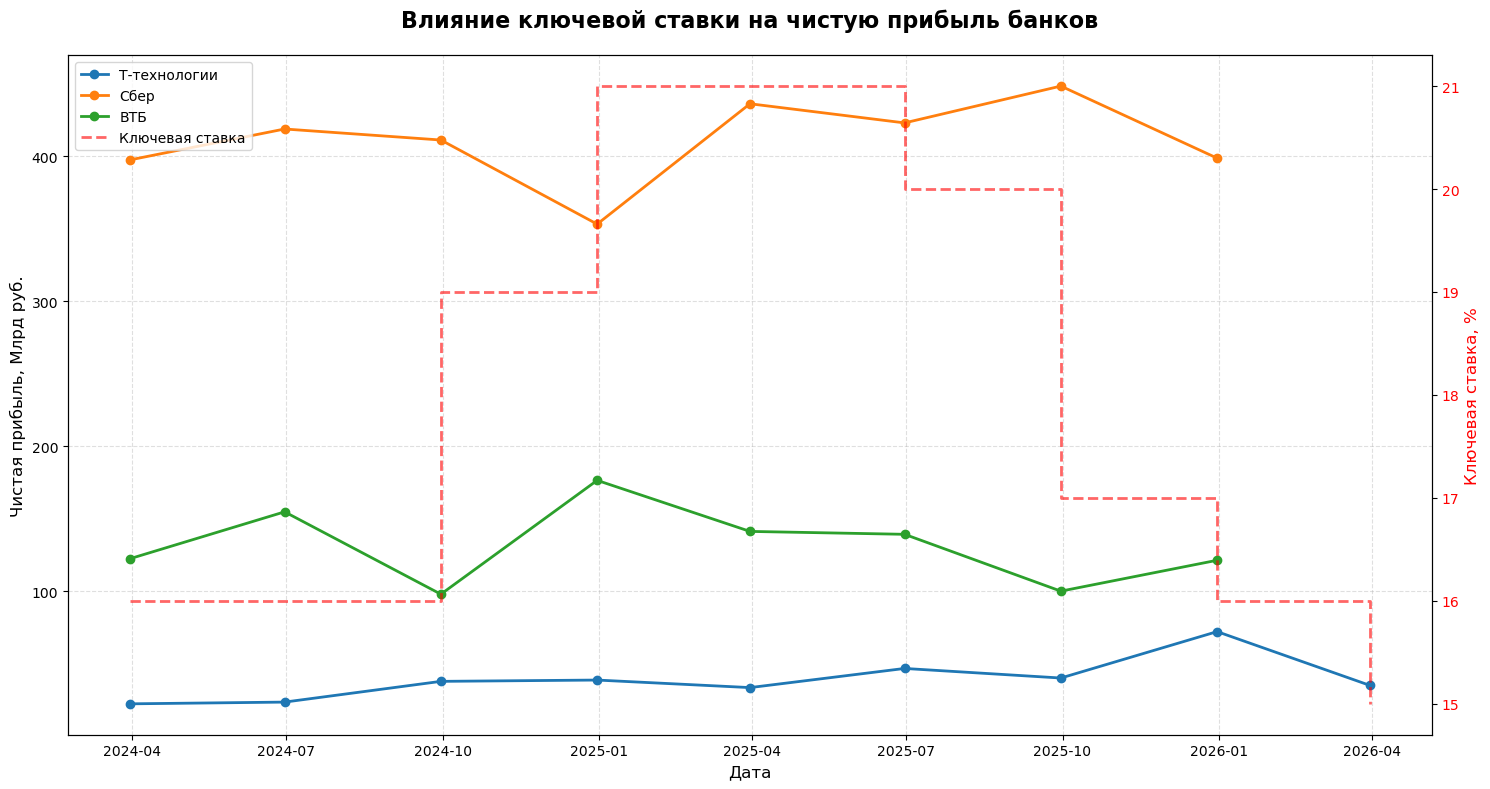

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(15, 8))

# Рисуем прибыль банков (Левая ось Y)
for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    ax.plot(bank_df['date'], bank_df['t_net_profit_bln_rub'], marker='o', linewidth=2, label=bank)

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Чистая прибыль, Млрд руб.', fontsize=12)

# Создаем правую ось для ставки
ax1 = ax.twinx()

# Важно: берем данные по ставке только для одного банка (например, Т-Банка), 
# чтобы не рисовать линию три раза поверх друг друга
stavka_data = df[df['bank'] == 'Т-технологии']
# Умножаем на 100, если в Excel ставка в долях (0.16 -> 16%)
ax1.step(stavka_data['date'], stavka_data['key_rate'] * 100, color='red', 
         linestyle='--', linewidth=2, alpha=0.6, where='post', label='Ключевая ставка')

ax1.set_ylabel('Ключевая ставка, %', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red') # Делаем цифры шкалы ставки красными

# 4. Настройка легенды (объединяем легенды с двух осей в одну)
lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax.legend(lines + lines1, labels + labels1, loc='upper left', fontsize=10)

# 5. Оформление
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.title('Влияние ключевой ставки на чистую прибыль банков', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 2. Регрессионный анализ: ROE vs Ключевая ставка (Т-Технологии)

In [ ]:
import pandas as pd
import statsmodels.api as sm

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)
#берем данные только по Т-тенхологиям
df_t = df[df['bank'] == 'Т-технологии'].copy()

# убедиться,что ROE в процентах
x = df_t['key_rate']
y = df_t['t_roe']

#добавим константу для расчета b
x = sm.add_constant(x)

#обучим модель и посмотрим результат
model = sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  t_roe   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                 -0.095
Method:                 Least Squares   F-statistic:                    0.3056
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.598
Time:                        09:28:26   Log-Likelihood:                 17.107
No. Observations:                   9   AIC:                            -30.21
Df Residuals:                       7   BIC:                            -29.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3656      0.110      3.314      0.0

## 3. Регрессионный анализ: ROE vs Ключевая ставка (Сбер)

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Загрузка данных
t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name='Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name='ВТБ')

t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'

df = pd.concat([t_bank, sber, vtb], ignore_index=True)

# 1. Фильтруем строго по Сберу
df_sber = df[df['bank'] == 'Сбер'].copy()
df_sber = df_sber[['key_rate', 't_roe']].dropna()
# 2. Проверьте название столбца ROE в файле! 
# Если на листе Сбера столбец называется 'roe', укажите 'roe'. Если 'sber_roe', то укажите его.
x = df_sber['key_rate']
y = df_sber['t_roe'] # Замените на точное имя столбца из листа 'Сбер'

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  t_roe   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.150
Method:                 Least Squares   F-statistic:                   0.08837
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.776
Time:                        09:37:38   Log-Likelihood:                 19.975
No. Observations:                   8   AIC:                            -35.95
Df Residuals:                       6   BIC:                            -35.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2548      0.071      3.592      0.0

## 4. Регрессионный анализ: ROE vs Ключевая ставка (ВТБ, без аномалии 2024-Q4)

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Загрузка данных

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name='Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name='ВТБ')

# Добавляем метку банка (необязательно для отдельной регрессии, но для порядка)
vtb['bank'] = 'ВТБ'

# Удаляем строку с аномалией (2024-12-31)
vtb_clean = vtb[vtb['date'] != '2024-12-31'].copy()

# Определяем X и Y
X = vtb_clean['key_rate']
Y = vtb_clean['t_roe']   # обрати внимание: s_roe, а не t_roe

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  t_roe   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.199
Method:                 Least Squares   F-statistic:                  0.002862
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.959
Time:                        10:12:27   Log-Likelihood:                 13.225
No. Observations:                   7   AIC:                            -22.45
Df Residuals:                       5   BIC:                            -22.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2000      0.150      1.333      0.2

c:\Users\1\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 5. Динамика роста кредитных портфелей vs Денежная масса M2

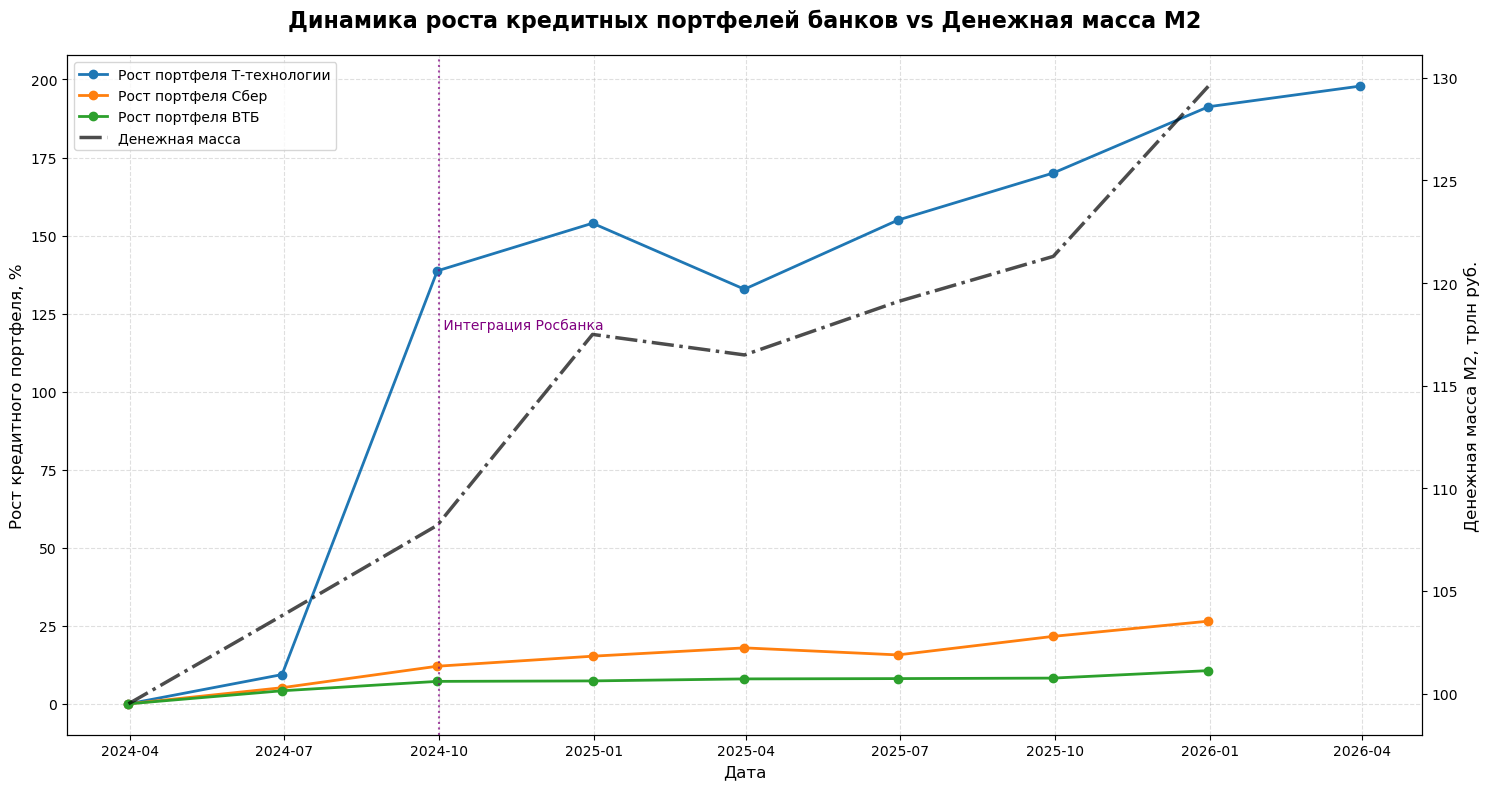

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(15, 8))

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank].sort_values('date')
    
    # Берем самое первое значение портфеля для этого банка (базовая точка)
    base_value = bank_df['t_credit_portfolio'].iloc[0]
    
    # Считаем рост в процентах относительно первой точки
    growth_pct = (bank_df['t_credit_portfolio'] / base_value - 1) * 100
    
    ax.plot(bank_df['date'], growth_pct, marker='o', linewidth=2, label=f'Рост портфеля {bank}')

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Рост кредитного портфеля, %', fontsize=12)
# Создаем правую ось для ставки
ax1 = ax.twinx()

# Важно: берем данные по ставке только для одного банка (например, Т-Банка), 
# чтобы не рисовать линию три раза поверх друг друга
m2_data = df[df['bank'] == 'Сбер']
# Умножаем на 100, если в Excel ставка в долях (0.16 -> 16%)
ax1.plot(m2_data['date'], m2_data['m2_trln_rub'], color = 'black',
         linestyle = '-.', linewidth=2.5, alpha=0.7, label='Денежная масса')

ax1.set_ylabel('Денежная масса М2, трлн руб.', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black') # Делаем цифры шкалы ставки красными

# 4. Настройка легенды (объединяем легенды с двух осей в одну)
lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax.legend(lines + lines1, labels + labels1, loc='upper left', fontsize=10)

# 5. Оформление
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.title('Динамика роста кредитных портфелей банков vs Денежная масса М2', fontsize=16, fontweight='bold', pad=20)
ax.axvline(pd.to_datetime('2024-10-01'), color='purple', linestyle=':', alpha=0.7)
ax.text(pd.to_datetime('2024-10-01'), 120, ' Интеграция Росбанка', color='purple', fontsize=10)
plt.tight_layout()
plt.show()


## 6. Сравнение эффективности: Рентабельность капитала (ROE)

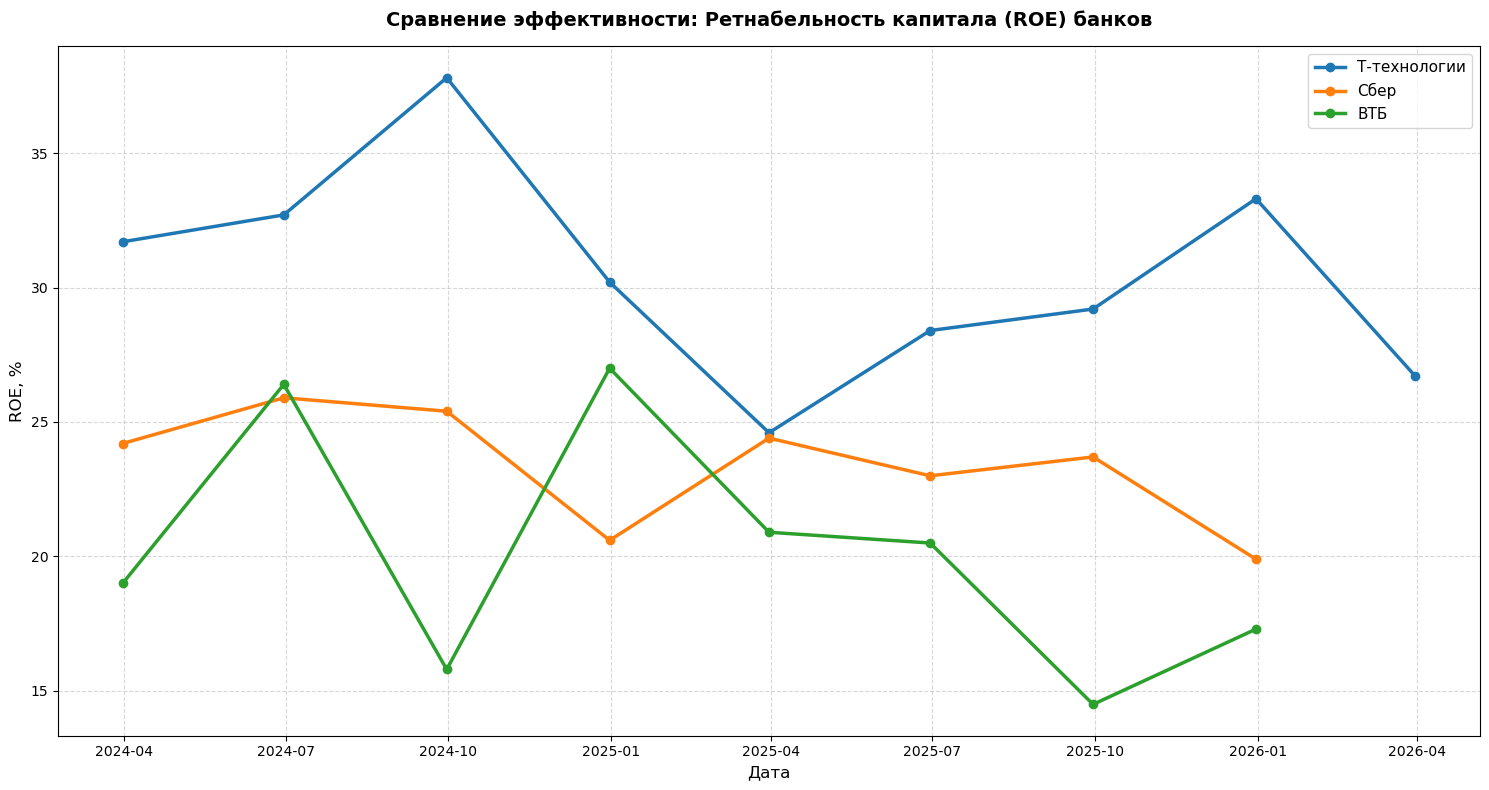

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

df['t_roe'] = df['t_roe'] * 100
# 3. Визуализация
fig, ax = plt.subplots(figsize=(15, 8))

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank].sort_values('date')
    ax.plot(bank_df['date'], bank_df['t_roe'], marker='o', linewidth = 2.5, label=bank)

ax.set_title('Сравнение эффективности: Ретнабельность капитала (ROE) банков', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Дата', fontsize= 12)
ax.set_ylabel('ROE, %', fontsize=12)

ax.grid(True, linestyle= '--', alpha = 0.5)
ax.legend(fontsize= 11, loc='best')

plt.tight_layout()
plt.show()

## 7. Сравнение чистых комиссионных доходов по кварталам

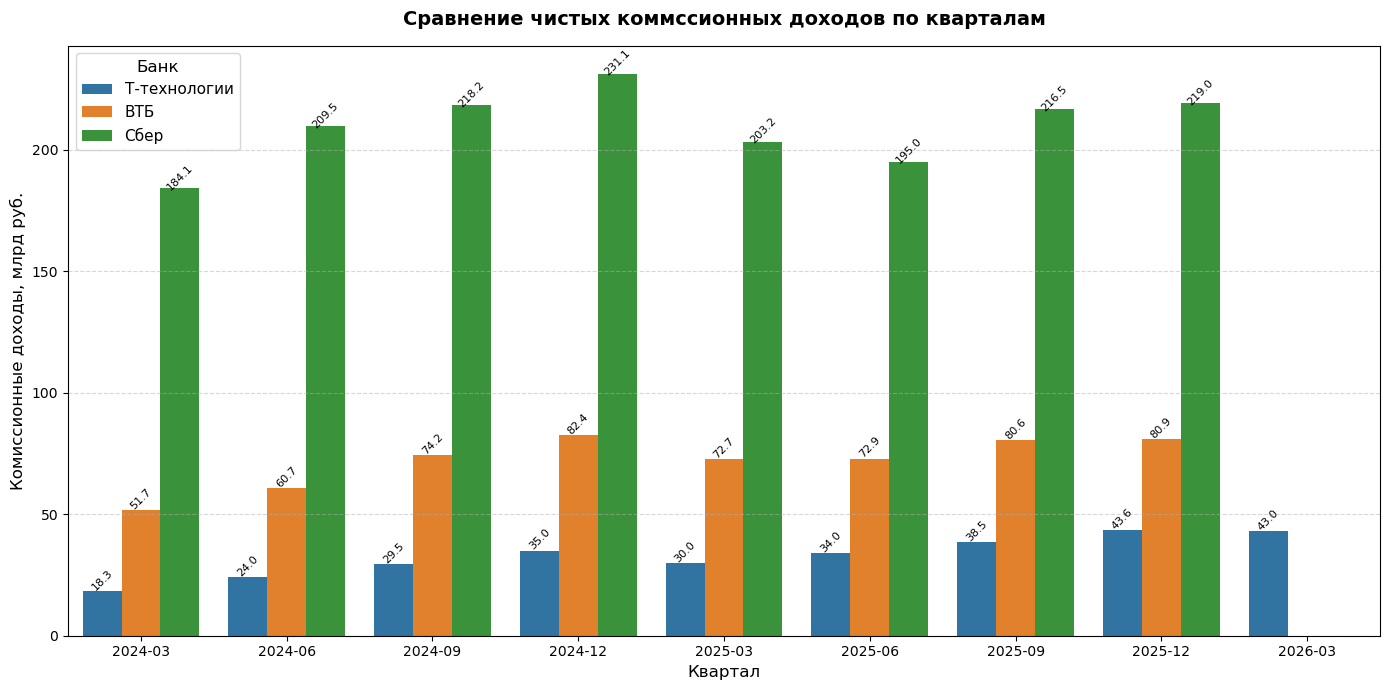

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'

df = pd.concat([t_bank, sber, vtb], ignore_index=True)

df['date_str'] = df['date'].dt.strftime('%Y-%m')
df = df.sort_values('date')

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data = df,
    x='date_str',
    y='t_commission_inc_bln_rub',
    hue='bank', 
    palette=['#1f77b4','#ff7f0e', '#2ca02c'] #Фирменные цвета
)

plt.title('Сравнение чистых коммссионных доходов по кварталам', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Квартал', fontsize=12)
plt.ylabel('Комиссионные доходы, млрд руб.', fontsize=12)

#Настройка сетки (только горизонтальные линии, чтобы не перегружать график)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Банк', fontsize=11, title_fontsize=12)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0,8),
                    textcoords='offset points',
                    fontsize=8, rotation=45)
        
plt.tight_layout()
plt.show()

## 8. Динамика роста чистых комиссионных доходов (%)

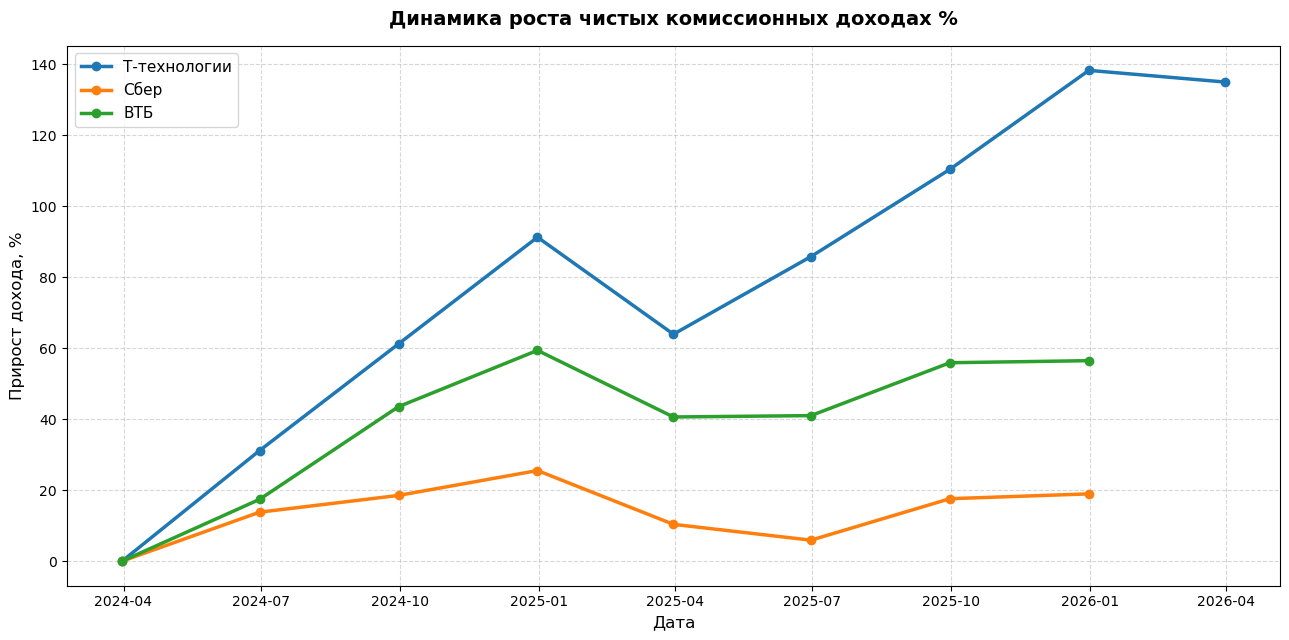

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

fig, ax = plt.subplots(figsize=(13,6.5))

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank].sort_values('date')

    #берем самое первое значение комиссионных доходов (базовая точка)
    base_val = bank_df['t_commission_inc_bln_rub'].iloc[0]

    #считаем прирост в % относительно первой точки
    #например: если было 18, а стало 36, то (36/18 - 1) * 100 = 100% (выросли в 2 раза)
    comm_growth_pct = (bank_df['t_commission_inc_bln_rub'] / base_val - 1) * 100

    ax.plot(bank_df['date'], comm_growth_pct, marker='o', linewidth = 2.5, label=bank)


#оформление
ax.set_title('Динамика роста чистых комиссионных доходах %', fontsize=14, fontweight='bold', pad= 15)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Прирост дохода, %', fontsize = 12)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

## 9. Сводная таблица метрик по банкам

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

df['t_roe'] = df['t_roe'] * 100
forecast_metrics = df.groupby('bank').agg({
    't_roe':['mean', 'std'],
    't_cor':['mean', 'std'],
    't_commission_inc_bln_rub':['mean', 'std'],
    't_net_profit_bln_rub':['mean', 'std']
}).round(2)


forecast_metrics.columns = [
    'ROE (Среднее)', 'ROE (Волатильность/Риск)',
    'COR(Среднее), COR (Волатильность/риск)',
    'Комиссии (Среднее, млрд)', 'Комиссии (Волатильность, млрд)',
    'Прибыль (Среднее, млрд)', 'Прибыль (Волатильность, млрд)'
]

print(forecast_metrics)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## 10. Очистка аномалии ВТБ (Q4 2024) и пересчёт метрик

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

t_bank = pd.read_excel(r't_blank.xlsx', sheet_name='T-технологии')
sber = pd.read_excel(r't_blank.xlsx', sheet_name = 'Сбер')
vtb = pd.read_excel(r't_blank.xlsx', sheet_name = 'ВТБ')

# Добавляем столбец с названием банка
t_bank['bank'] = 'Т-технологии'
sber['bank'] = 'Сбер'
vtb['bank'] = 'ВТБ'


df = pd.concat([t_bank, sber, vtb], ignore_index=True)

df['is_outlier'] = False

df.loc[(df['bank'] == 'ВТБ') & (df['date'] == '2024-12-31'), 'is_outlier'] = True


df_clean = df.drop(index=df[(df['bank'] == 'ВТБ') & (df['date'] == '2024-12-31')].index)

forecast_clean = df_clean.groupby('bank').agg({
    't_roe':'mean',
    't_cor':'mean'
}).round(4)

print(forecast_clean)

print("Было (с выбросом):", df[df['bank']=='ВТБ']['t_roe'].mean())
print("Стало (без выброса):", df_clean[df_clean['bank'] =='ВТБ']['t_roe'].mean())

               t_roe   t_cor
bank                        
ВТБ           0.1920  0.0090
Сбер          0.2339  0.0114
Т-технологии  0.3051  0.0644
Было (с выбросом): 0.20175
Стало (без выброса): 0.192


## 11. Прогноз рентабельности ROE на остаток 2026 года (3 сценария)

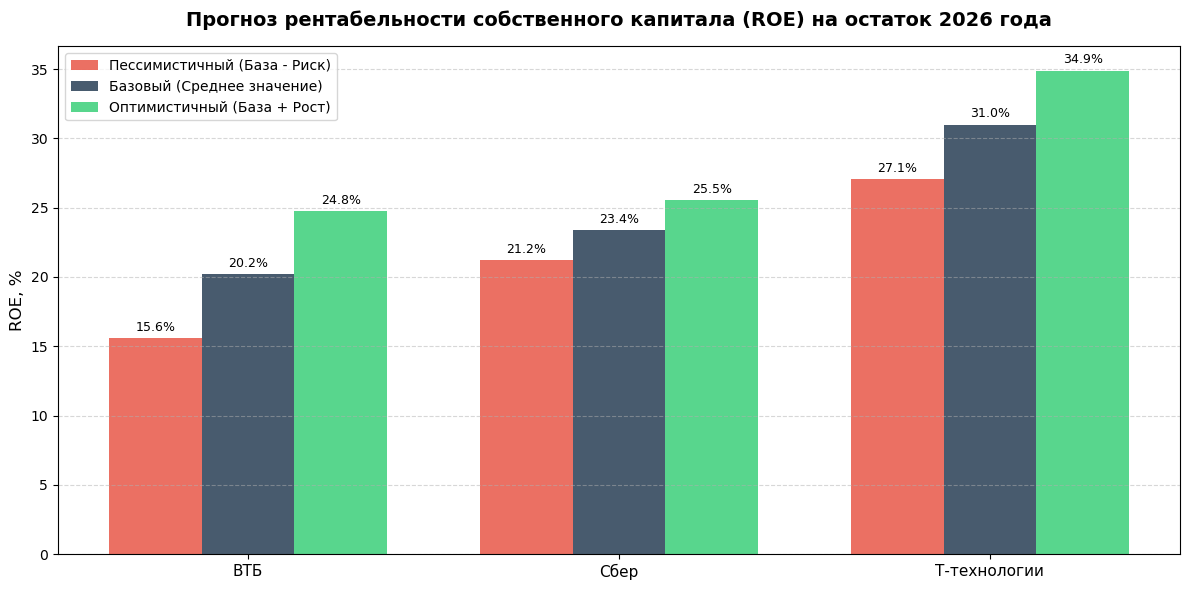

In [7]:
import matplotlib.pyplot as plt
import numpy as np


banks = ['ВТБ','Сбер', 'Т-технологии']
means = [20.18, 23.39,30.99]
stds = [4.58, 2.15 , 3.90]

pessimistic = [m - s for m,s in zip(means, stds)]
optimistic = [m + s for m,s in zip(means, stds)]

x = np.arange(len(banks))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

#рисуем три сценария
rects1 = ax.bar(x - width, pessimistic, width, label='Пессимистичный (База - Риск)', color='#e74c3c', alpha=0.8)
rects2 = ax.bar(x, means, width, label='Базовый (Среднее значение)', color='#34495e', alpha=0.9)
rects3 = ax.bar(x + width, optimistic, width, label='Оптимистичный (База + Рост)', color='#2ecc71', alpha=0.8)

ax.set_title('Прогноз рентабельности собственного капитала (ROE) на остаток 2026 года', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('ROE, %', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(banks, fontsize = 11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

#функция для добавления подписей
def autolabel(rects):
    for rect in rects:
        height = rect.get_height() #---измеряет высоту текущего прямоугольника, будущий y
        ax.annotate(f'{height:.1f}%', #--- annotate - это команда, чтобы сделать текст на графике, дальше это число какой процент рентабельности будет
                    xy=(rect.get_x() + rect.get_width() / 2, height),   #----сначала идет x, где мы находим левый край столбика с помощью get_x, а потом добавляем ровно половину его ширины, то есть get_width() / 2
                    xytext = (0,3),     #--- 0 тут это x, а 3 - это y, с помощью которого мы поднимаем текст вверх
                    textcoords='offset points', #---координаты для текста в виде отступа
                    ha='center', va='bottom', fontsize=9)   #ha='center' --центрирует текст по горизонтали, va='bottom' - привязывает нижний край текста к нашей точке, fontsize=9 -- делает шрифт маленьким и аккуратным
        


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()
